In [2]:
# ============================================================
# Cell 1 — Environment, Imports, Seeds (Stable & Kaggle-safe)
# ============================================================
import os, random, math, time, json, sys
from glob import glob
from pathlib import Path
from collections import Counter

# Core Libraries
import numpy as np
import pandas as pd
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

# TIMM Models
import timm

# Optional SMP
try:
    import segmentation_models_pytorch as smp
    SMP_AVAILABLE = True
except Exception:
    SMP_AVAILABLE = False

# Augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Post-processing
from skimage.morphology import remove_small_objects, closing, disk

# ============================================================
# Device & Seeds
# ============================================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # FIX: deterministic=True and benchmark=True conflict with each other.
    # benchmark=True finds fastest algorithm (non-deterministic).
    # Since input size is fixed at 224x224, benchmark=True gives speed with no downside.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"torch       : {torch.__version__}")
print(f"timm        : {timm.__version__}")
print(f"SMP available: {SMP_AVAILABLE}")
print(f"SEED        : {SEED}")



Device      : cuda
torch       : 2.6.0+cu124
timm        : 1.0.19
SMP available: False
SEED        : 42


In [3]:
# ============================================================
# Cell 2 — Paths, Dataset Loading & Pair Validation
# ============================================================
import os
import re
from glob import glob
from pathlib import Path

# ============================================================
# Paths
# ============================================================
BASE = "/kaggle/input/wcebleedgen/WCEBleedGen (updated)/WCEBleedGen (updated)"
assert os.path.exists(BASE), f"Base path not found: {BASE}"

BLEED_IMG_DIR  = os.path.join(BASE, "bleeding",     "Images")
BLEED_MASK_DIR = os.path.join(BASE, "bleeding",     "Annotations")
NON_IMG_DIR    = os.path.join(BASE, "non-bleeding", "images")
NON_MASK_DIR   = os.path.join(BASE, "non-bleeding", "annotation")

# Load & sort
bleed_imgs  = sorted(glob(os.path.join(BLEED_IMG_DIR,  "*.png")))
bleed_masks = sorted(glob(os.path.join(BLEED_MASK_DIR, "*.png")))
non_imgs    = sorted(glob(os.path.join(NON_IMG_DIR,    "*.png")))
non_masks   = sorted(glob(os.path.join(NON_MASK_DIR,   "*.png")))

print("Bleeding images :", len(bleed_imgs))
print("Bleeding masks  :", len(bleed_masks))
print("Non-bleed images:", len(non_imgs))
print("Non-bleed masks :", len(non_masks))

assert len(bleed_imgs) == len(bleed_masks), "Count mismatch in bleeding class"
assert len(non_imgs)   == len(non_masks),   "Count mismatch in non-bleeding class"

# Combined dataset
all_imgs  = bleed_imgs + non_imgs
all_masks = bleed_masks + non_masks

print(f"\nTotal images : {len(all_imgs)}")
print(f"Total masks  : {len(all_masks)}")
assert len(all_imgs) == len(all_masks), "Global img-mask count mismatch"

# ============================================================
# Pair Validation — numeric ID matching
# ============================================================
def extract_id(fname):
    """
    Extracts the last numeric ID from a filename.
    e.g. 'img- (1).jpg' → 1,  'image_23_mask.png' → 23
    """
    nums = re.findall(r'\d+', fname)
    return int(nums[-1]) if nums else None


def check_pairs(img_list, mask_list, label):
    print(f"\nChecking pair integrity: {label}")
    print(f"  Images: {len(img_list)} | Masks: {len(mask_list)}")

    img_ids  = sorted([extract_id(os.path.basename(p)) for p in img_list])
    mask_ids = sorted([extract_id(os.path.basename(p)) for p in mask_list])

    if len(img_ids) != len(mask_ids):
        raise AssertionError(
            f"[COUNT ERROR] {label}: count mismatch — "
            f"Images: {len(img_ids)}, Masks: {len(mask_ids)}"
        )

    mismatches = [(i, a, b) for i, (a, b) in enumerate(zip(img_ids, mask_ids)) if a != b]
    if mismatches:
        # Report ALL mismatches at once instead of stopping at the first one
        msg = "\n".join(f"  index {i}: Image ID {a} vs Mask ID {b}"
                        for i, a, b in mismatches)
        raise AssertionError(f"[PAIR ERROR] {label}: {len(mismatches)} mismatch(es):\n{msg}")

    print(f"  ✓ All {len(img_ids)} pairs OK for {label}")


# Now paths exist → safe to run
check_pairs(bleed_imgs,  bleed_masks, "Bleeding")
check_pairs(non_imgs,    non_masks,   "Non-Bleeding")
print("\n✅ Dataset loaded and validated successfully.")

Bleeding images : 1309
Bleeding masks  : 1309
Non-bleed images: 1309
Non-bleed masks : 1309

Total images : 2618
Total masks  : 2618

Checking pair integrity: Bleeding
  Images: 1309 | Masks: 1309
  ✓ All 1309 pairs OK for Bleeding

Checking pair integrity: Non-Bleeding
  Images: 1309 | Masks: 1309
  ✓ All 1309 pairs OK for Non-Bleeding

✅ Dataset loaded and validated successfully.


In [4]:
# ============================================================
# Cell 2 — Paths, Loading & Sanity Checks
# ============================================================
import re

BASE = "/kaggle/input/wcebleedgen/WCEBleedGen (updated)/WCEBleedGen (updated)"
assert os.path.exists(BASE), f"Base path not found: {BASE}"

# Directories
BLEED_IMG_DIR  = os.path.join(BASE, "bleeding",     "Images")
BLEED_MASK_DIR = os.path.join(BASE, "bleeding",     "Annotations")
NON_IMG_DIR    = os.path.join(BASE, "non-bleeding", "images")
NON_MASK_DIR   = os.path.join(BASE, "non-bleeding", "annotation")

# Verify all subdirectories exist before globbing
for d in [BLEED_IMG_DIR, BLEED_MASK_DIR, NON_IMG_DIR, NON_MASK_DIR]:
    assert os.path.exists(d), f"Directory not found: {d}"

# Load & sort
bleed_imgs  = sorted(glob(os.path.join(BLEED_IMG_DIR,  "*.png")))
bleed_masks = sorted(glob(os.path.join(BLEED_MASK_DIR, "*.png")))
non_imgs    = sorted(glob(os.path.join(NON_IMG_DIR,    "*.png")))
non_masks   = sorted(glob(os.path.join(NON_MASK_DIR,   "*.png")))

# ============================================================
# FIX: Numeric ID-based pairing check
# Simple alphabetical sort can silently mis-pair files like
# "img-(2).png" and "ann-(20).png". Numeric extraction is safer.
# ============================================================
def extract_id(fname):
    nums = re.findall(r'\d+', os.path.basename(fname))
    return int(nums[-1]) if nums else None

def check_pairs(img_list, mask_list, label):
    print(f"\n  Checking: {label}")
    print(f"  Images: {len(img_list)} | Masks: {len(mask_list)}")

    if len(img_list) != len(mask_list):
        raise AssertionError(
            f"[COUNT ERROR] {label}: "
            f"Images={len(img_list)}, Masks={len(mask_list)}"
        )

    img_ids  = [extract_id(p) for p in img_list]
    mask_ids = [extract_id(p) for p in mask_list]

    mismatches = [
        (i, a, b) for i, (a, b) in enumerate(zip(img_ids, mask_ids)) if a != b
    ]
    if mismatches:
        raise AssertionError(
            f"[PAIR ERROR] {label}: {len(mismatches)} mismatches found.\n"
            f"First mismatch → index {mismatches[0][0]}: "
            f"img_id={mismatches[0][1]}, mask_id={mismatches[0][2]}"
        )

    print(f"  ✓ All {len(img_list)} pairs matched correctly.")

# Run checks
print("=" * 45)
print("Pair Validation")
print("=" * 45)
check_pairs(bleed_imgs, bleed_masks, "Bleeding")
check_pairs(non_imgs,   non_masks,   "Non-Bleeding")

# Combine
all_imgs  = bleed_imgs + non_imgs
all_masks = bleed_masks + non_masks

assert len(all_imgs) == len(all_masks), "Global img-mask count mismatch"

# Summary
print(f"\n{'='*45}")
print(f"  Bleeding     : {len(bleed_imgs)} images, {len(bleed_masks)} masks")
print(f"  Non-Bleeding : {len(non_imgs)} images, {len(non_masks)} masks")
print(f"  Total        : {len(all_imgs)} images, {len(all_masks)} masks")
print(f"{'='*45}")

Pair Validation

  Checking: Bleeding
  Images: 1309 | Masks: 1309
  ✓ All 1309 pairs matched correctly.

  Checking: Non-Bleeding
  Images: 1309 | Masks: 1309
  ✓ All 1309 pairs matched correctly.

  Bleeding     : 1309 images, 1309 masks
  Non-Bleeding : 1309 images, 1309 masks
  Total        : 2618 images, 2618 masks


In [ ]:
# ==========================================================
# ✅ Cell 3 - Dataset + transforms (Albumentations 2.x FIXED)
# ==========================================================
IMG_SIZE = 224

def get_train_transforms():
    return A.Compose([
        # Albumentations 2.x requires all 3: scale, ratio, size
        A.RandomResizedCrop(
            scale=(0.8, 1.0),
            ratio=(0.9, 1.1),
            size=(IMG_SIZE, IMG_SIZE),
            p=0.6
        ),

        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),

        A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.1,
            rotate_limit=20,
            p=0.6
        ),

        A.OneOf([A.GaussNoise(), A.ISONoise()], p=0.3),
        A.OneOf([A.MotionBlur(), A.MedianBlur(), A.Blur()], p=0.2),
        A.OneOf([A.RandomBrightnessContrast(), A.HueSaturationValue()], p=0.6),

        # Albumentations 2.x CoarseDropout API
        A.CoarseDropout(
            max_holes=8,
            hole_height_range=(8, 16),
            hole_width_range=(8, 16),
            fill_value=0,
            mask_fill_value=0,
            p=0.2
        ),

        A.Normalize(),
        ToTensorV2(),
    ], additional_targets={'mask': 'mask'})


def get_valid_transforms():
    return A.Compose([
        # Resize still works with height & width
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(),
        ToTensorV2(),
    ], additional_targets={'mask': 'mask'})


class WCEBleedDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transforms=None):
        assert len(image_paths) == len(mask_paths)
        self.image_paths = list(image_paths)
        self.mask_paths = list(mask_paths)
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32)
        mask = (mask > 127).astype(np.float32)

        if self.transforms:
            data = self.transforms(image=img, mask=mask)
            img, mask = data["image"], data["mask"]

        # Ensure correct shape
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img.float(), mask.float()



In [5]:
# ============================================================
# Cell 3 — Dataset Class + Transforms (Albumentations 2.x)
# ============================================================
IMG_SIZE = 224

def get_train_transforms():
    return A.Compose([
        A.RandomResizedCrop(
            size=(IMG_SIZE, IMG_SIZE),
            scale=(0.8, 1.0),
            ratio=(0.9, 1.1),
            p=0.6
        ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=20, p=0.6),
        # FIX: Removed ElasticTransform — alpha_affine param was removed in Albumentations 2.x
        # and would throw TypeError at runtime
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.2),
        A.OpticalDistortion(distort_limit=0.2, p=0.2),
        A.OneOf([
            A.RandomBrightnessContrast(),
            A.HueSaturationValue()
        ], p=0.6),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.ISONoise()
        ], p=0.3),
        A.OneOf([
            A.MotionBlur(blur_limit=3),
            A.MedianBlur(blur_limit=3),
            A.Blur(blur_limit=3)
        ], p=0.2),
        # FIX: Albumentations 2.x uses num_holes_range / hole_height_range / hole_width_range
        # max_holes, min_holes, max_height, max_width are deprecated and raise errors
        A.CoarseDropout(
            num_holes_range=(3, 8),
            hole_height_range=(8, 16),
            hole_width_range=(8, 16),
            fill_value=0,
            mask_fill_value=0,
            p=0.2
        ),
        A.Normalize(),
        ToTensorV2()
    ], additional_targets={"mask": "mask"})


def get_valid_transforms():
    return A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(),
        ToTensorV2(),
    ], additional_targets={"mask": "mask"})


class WCEBleedDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transforms=None):
        assert len(image_paths) == len(mask_paths), \
            f"Mismatch: {len(image_paths)} images vs {len(mask_paths)} masks"
        self.image_paths = list(image_paths)
        self.mask_paths  = list(mask_paths)
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32)
        mask = (mask > 127).astype(np.float32)

        if self.transforms:
            data = self.transforms(image=img, mask=mask)
            img, mask = data["image"], data["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img.float(), mask.float()




In [6]:
# ============================================================
# Cell 4 — Split + Dataloaders
# ============================================================
from sklearn.model_selection import train_test_split

# FIX: Seeds already set in Cell 1 via seed_everything().
# Re-setting them here is redundant. Removed duplicates.

def is_bleeding(path):
    parent = Path(path).parent.name.lower()
    return 1 if parent == "bleeding" else 0

labels = [is_bleeding(p) for p in all_imgs]

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_imgs, all_masks,
    test_size=0.10,
    shuffle=True,
    stratify=labels,
    random_state=SEED
)
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# Weighted sampler (keeps structure for future imbalanced cases)
train_labels    = [is_bleeding(p) for p in train_imgs]
class_counts    = Counter(train_labels)
total           = len(train_labels)
weight_for_class = {cls: total / class_counts[cls] for cls in class_counts}
weights          = [weight_for_class[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=weights,
    num_samples=len(weights),
    replacement=True
)

BATCH_SIZE = 8

train_ds_shared = WCEBleedDataset(train_imgs, train_masks, transforms=get_train_transforms())
val_ds_shared   = WCEBleedDataset(val_imgs,   val_masks,   transforms=get_valid_transforms())

train_loader_shared = DataLoader(
    train_ds_shared,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True   # FIX: keeps workers alive between epochs, faster on Kaggle
)
val_loader_shared = DataLoader(
    val_ds_shared,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True
)

imgs, masks = next(iter(train_loader_shared))
print(f"Batch shapes → imgs: {imgs.shape} | masks: {masks.shape}")




Train: 2356 | Val: 262


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_47/3403722652.py:26: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),
/tmp/ipykernel_47/3403722652.py:36: UserWarning: Argument(s) 'fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Batch shapes → imgs: torch.Size([8, 3, 224, 224]) | masks: torch.Size([8, 1, 224, 224])


In [ ]:
# ==========================================================
# ✅ Cell 5 - SwinUNet-Small (offline-safe, robust loading)
# ==========================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from pathlib import Path

# --- CONFIG ---
SWIN_WEIGHTS_PATH = "/kaggle/input/safetensors/model.safetensors"  # change if needed
ENCODER_NAME = "swin_small_patch4_window7_224"
NUM_CLASSES = 1

# --- helper: safe safetensors loader with fallback to torch.load ---
def safe_load_weights(path):
    path = Path(path)
    assert path.exists(), f"Weight file not found: {path}"
    # try safetensors first
    try:
        from safetensors.torch import load_file as st_load
        state = st_load(str(path))
        print("Loaded safetensors:", path.name)
        # safetensors returns mapping of numpy tensors -> convert to tensors if needed
        return {k: (v if isinstance(v, torch.Tensor) else torch.as_tensor(v)) for k, v in state.items()}
    except Exception as e:
        print("safetensors load failed:", e)
        print("Falling back to torch.load (may require .pth/.pt file)...")
        st = torch.load(str(path), map_location="cpu")
        # if checkpoint contains 'state_dict' or 'model', try to extract
        if isinstance(st, dict) and ("state_dict" in st or "model" in st):
            if "state_dict" in st:
                raw = st["state_dict"]
            else:
                raw = st.get("model", st)
            if isinstance(raw, dict):
                return raw
        if isinstance(st, dict):
            return st
        raise RuntimeError("Unable to interpret checkpoint format.")

# --- key remapping / intersection utility ---
def smart_state_dict_match(model, raw_state):
    """
    Attempt to match keys from raw_state to model.state_dict() keys.
    Returns a new_state_dict usable for load_state_dict(..., strict=False).
    Strategy:
      - try direct intersection
      - try removing common prefixes: 'model.', 'module.', 'encoder.', 'backbone.'
      - try adding 'encoder.' prefix if that helps
    """
    model_keys = set(model.state_dict().keys())
    raw_keys = list(raw_state.keys())

    # direct intersection
    intersect = model_keys & set(raw_keys)
    if len(intersect) > 0:
        matched = {k: raw_state[k] for k in raw_keys if k in model_keys}
        print(f"Direct key intersection size: {len(matched)}")
        return matched

    # try stripping common prefixes
    prefixes = ["model.", "module.", "encoder.", "backbone.", "net."]
    for p in prefixes:
        stripped = {k[len(p):] if k.startswith(p) else k: v for k, v in raw_state.items()}
        intersect = model_keys & set(stripped.keys())
        if len(intersect) > 0:
            matched = {k: stripped[k] for k in stripped.keys() if k in model_keys}
            print(f"Matched after stripping prefix '{p}': {len(matched)}")
            return matched

    # try adding common prefixes to raw keys
    for p in prefixes:
        prefixed = {p + k: v for k, v in raw_state.items()}
        intersect = model_keys & set(prefixed.keys())
        if len(intersect) > 0:
            matched = {k: prefixed[k] for k in prefixed.keys() if k in model_keys}
            print(f"Matched after adding prefix '{p}': {len(matched)}")
            return matched

    # As a last resort try fuzzy matching by suffix
    matched = {}
    model_key_list = list(model_keys)
    for rk, rv in raw_state.items():
        for mk in model_key_list:
            if mk.endswith(rk) or rk.endswith(mk):
                matched[mk] = rv
                break
    if matched:
        print(f"Fuzzy matched keys: {len(matched)}")
        return matched

    # nothing matched
    print("No matching keys found between checkpoint and model.")
    return {}

# ----------------------------------------------------------
# Decoder blocks (kept close to your original design)
# ----------------------------------------------------------
class ConvBlockBase(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class DecoderBlockSwin(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlockBase(out_ch + (skip_ch if skip_ch else 0), out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if skip.size(2) != x.size(2) or skip.size(3) != x.size(3):
                skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ----------------------------------------------------------
# SwinUNetSmall
# ----------------------------------------------------------
class SwinUNetSmall(nn.Module):
    def __init__(self, encoder_name=ENCODER_NAME, num_classes=NUM_CLASSES, pretrained_state=None):
        super().__init__()

        # Create encoder (no pretrained flag; we will load offline)
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=False,
            features_only=True,
            in_chans=3
        )

        # If pretrained_state provided, attempt smart mapping + load
        if pretrained_state is not None:
            print("Attempting to load pretrained weights into encoder...")
            mapped = smart_state_dict_match(self.encoder, pretrained_state)
            if mapped:
                res = self.encoder.load_state_dict(mapped, strict=False)
                # load_state_dict returns a NamedTuple; print lengths
                missing = len(res.missing_keys) if hasattr(res, "missing_keys") else None
                unexpected = len(res.unexpected_keys) if hasattr(res, "unexpected_keys") else None
                print(f"Loaded mapped weights. missing_keys={missing}, unexpected_keys={unexpected}")
            else:
                print("No mapped keys to load (continuing with random init).")

        enc_ch = self.encoder.feature_info.channels()
        print("Encoder channels:", enc_ch)

        # Decoder (channels chosen to reduce/increase progressively)
        self.center = ConvBlockBase(enc_ch[-1], enc_ch[-1])
        # choose decoder channels carefully
        self.dec4 = DecoderBlockSwin(enc_ch[-1], enc_ch[-2], 512)
        self.dec3 = DecoderBlockSwin(512, enc_ch[-3], 256)
        self.dec2 = DecoderBlockSwin(256, enc_ch[-4], 128)
        self.dec1 = DecoderBlockSwin(128, 0, 64)

        self.final = nn.Sequential(
            ConvBlockBase(64, 32),
            nn.Conv2d(32, num_classes, 1)
        )

    def _to_nchw(self, feat):
        # timm 'features_only' returns tensors (B,C,H,W) normally,
        # keep it safe and only permute if shape looks like NHWC
        if feat.ndim == 4 and feat.shape[1] < feat.shape[-1]:
            feat = feat.permute(0, 3, 1, 2).contiguous()
        return feat

    def forward(self, x):
        feats = [self._to_nchw(f) for f in self.encoder(x)]
        x = self.center(feats[-1])
        x = self.dec4(x, feats[-2])
        x = self.dec3(x, feats[-3])
        x = self.dec2(x, feats[-4])
        x = self.dec1(x)
        out = self.final(x)
        out = F.interpolate(out, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        return out

# ----------------------------------------------------------
# Instantiate model and try loading weights (if provided)
# ----------------------------------------------------------
# safe load
pretrained_state = None
if os.path.exists(SWIN_WEIGHTS_PATH):
    try:
        pretrained_state = safe_load_weights(SWIN_WEIGHTS_PATH)
    except Exception as e:
        print("Weight loading failed:", e)
        pretrained_state = None
else:
    print("No offline weight file found at:", SWIN_WEIGHTS_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swin_model = SwinUNetSmall(pretrained_state=pretrained_state).to(device)

# sanity forward
with torch.no_grad():
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    y = swin_model(x)
    print("SwinUNet forward OK | output:", y.shape)


In [7]:
# ============================================================
# Cell 5 — SwinUNet-Small Model
# ============================================================
from pathlib import Path

SWIN_WEIGHTS_PATH = "/kaggle/input/safetensors/model.safetensors"
ENCODER_NAME      = "swin_small_patch4_window7_224"
NUM_CLASSES       = 1


def safe_load_weights(path):
    path = Path(path)
    assert path.exists(), f"Weight file not found: {path}"
    try:
        from safetensors.torch import load_file as st_load
        state = st_load(str(path))
        print(f"Loaded safetensors: {path.name}")
        return {k: (v if isinstance(v, torch.Tensor) else torch.as_tensor(v))
                for k, v in state.items()}
    except Exception as e:
        print(f"safetensors load failed: {e} — falling back to torch.load")
        st = torch.load(str(path), map_location="cpu")
        if isinstance(st, dict):
            raw = st.get("state_dict", st.get("model", st))
            return raw if isinstance(raw, dict) else dict(raw)
        raise RuntimeError("Unable to interpret checkpoint format.")


def smart_state_dict_match(model, raw_state):
    model_keys = set(model.state_dict().keys())
    raw_keys   = list(raw_state.keys())

    # Direct match
    intersect = model_keys & set(raw_keys)
    if intersect:
        matched = {k: raw_state[k] for k in raw_keys if k in model_keys}
        print(f"Direct key match: {len(matched)} keys")
        return matched

    # Strip common prefixes
    for p in ["model.", "module.", "encoder.", "backbone.", "net."]:
        stripped  = {(k[len(p):] if k.startswith(p) else k): v for k, v in raw_state.items()}
        intersect = model_keys & set(stripped.keys())
        if intersect:
            matched = {k: stripped[k] for k in stripped if k in model_keys}
            print(f"Matched after stripping '{p}': {len(matched)} keys")
            return matched

    # Add prefixes
    for p in ["model.", "module.", "encoder.", "backbone.", "net."]:
        prefixed  = {p + k: v for k, v in raw_state.items()}
        intersect = model_keys & set(prefixed.keys())
        if intersect:
            matched = {k: prefixed[k] for k in prefixed if k in model_keys}
            print(f"Matched after adding '{p}': {len(matched)} keys")
            return matched

    # Fuzzy suffix match as last resort
    matched, model_key_list = {}, list(model_keys)
    for rk, rv in raw_state.items():
        for mk in model_key_list:
            if mk.endswith(rk) or rk.endswith(mk):
                matched[mk] = rv
                break
    print(f"Fuzzy match: {len(matched)} keys")
    return matched


class ConvBlockBase(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        # FIX: Removed the broken SE block — AdaptiveAvgPool2d inside Sequential
        # just squeezes spatial dims, the output was fed straight into ReLU with
        # wrong shape. It did nothing useful and would cause shape errors in deep
        # decoders. Removed entirely.

    def forward(self, x):
        return self.block(x)


class DecoderBlockSwin(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlockBase(out_ch + (skip_ch if skip_ch else 0), out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if skip.shape[2:] != x.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class SwinUNetSmall(nn.Module):
    def __init__(self, encoder_name=ENCODER_NAME, num_classes=NUM_CLASSES,
                 pretrained_state=None):
        super().__init__()
        self.encoder = timm.create_model(
            encoder_name, pretrained=False, features_only=True, in_chans=3
        )

        if pretrained_state is not None:
            print("Loading pretrained weights into encoder...")
            mapped = smart_state_dict_match(self.encoder, pretrained_state)
            if mapped:
                res = self.encoder.load_state_dict(mapped, strict=False)
                print(f"Loaded mapped weights — "
                      f"missing: {len(res.missing_keys)}, "
                      f"unexpected: {len(res.unexpected_keys)}")
            else:
                print("⚠️ No weights matched — encoder is randomly initialized.")

        enc_ch = self.encoder.feature_info.channels()
        print(f"Encoder feature channels: {enc_ch}")

        self.center = ConvBlockBase(enc_ch[-1], enc_ch[-1])
        self.dec4   = DecoderBlockSwin(enc_ch[-1], enc_ch[-2], 512)
        self.dec3   = DecoderBlockSwin(512,        enc_ch[-3], 256)
        self.dec2   = DecoderBlockSwin(256,        enc_ch[-4], 128)
        self.dec1   = DecoderBlockSwin(128,        0,          64)

        self.final = nn.Sequential(
            ConvBlockBase(64, 32),
            nn.Conv2d(32, num_classes, 1)
        )

    def _to_nchw(self, feat):
        # Swin outputs (B, H, W, C) — convert to (B, C, H, W)
        if feat.ndim == 4 and feat.shape[1] < feat.shape[-1]:
            feat = feat.permute(0, 3, 1, 2).contiguous()
        return feat

    def forward(self, x):
        feats = [self._to_nchw(f) for f in self.encoder(x)]
        x = self.center(feats[-1])
        x = self.dec4(x, feats[-2])
        x = self.dec3(x, feats[-3])
        x = self.dec2(x, feats[-4])
        x = self.dec1(x)
        out = self.final(x)
        # FIX: align_corners=False is correct for bilinear upsampling to a fixed grid.
        # align_corners=True is only recommended for exact coordinate alignment tasks.
        out = F.interpolate(out, size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        return out


pretrained_state = safe_load_weights(SWIN_WEIGHTS_PATH) \
    if os.path.exists(SWIN_WEIGHTS_PATH) else None

swin_model = SwinUNetSmall(pretrained_state=pretrained_state).to(device)

with torch.no_grad():
    _x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    _y = swin_model(_x)
    print(f"✅ SwinUNet forward OK | output: {_y.shape}")


Loaded safetensors: model.safetensors
Loading pretrained weights into encoder...
Direct key match: 4 keys
Loaded mapped weights — missing: 321, unexpected: 0
Encoder feature channels: [96, 192, 384, 768]
✅ SwinUNet forward OK | output: torch.Size([1, 1, 224, 224])


In [8]:
# ============================================================
# Cell 6 — EfficientNet-B4 UNet (CBAM + Deep Supervision)
# ============================================================
DROPOUT_RATE       = 0.1
ENCODER_PRETRAINED = True
DEEP_SUPERVISION   = True


class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=16):
        super().__init__()
        mid = max(in_planes // reduction, 1)  # FIX: guard against reduction > channels
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAMBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.channel_att = ChannelAttention(in_ch)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        return self.spatial_att(self.channel_att(x))


class ConvBlockEff(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=DROPOUT_RATE):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlockEff(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlockEff(out_ch + (skip_ch if skip_ch else 0), out_ch)
        self.att  = CBAMBlock(out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if skip.shape[2:] != x.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:],
                                     mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.att(self.conv(x))


class EffUNetAttentionDeepSup(nn.Module):
    def __init__(self, encoder_name="efficientnet_b4", pretrained=ENCODER_PRETRAINED,
                 num_classes=NUM_CLASSES, deep_supervision=DEEP_SUPERVISION):
        super().__init__()
        self.encoder = timm.create_model(
            encoder_name, features_only=True, pretrained=pretrained, in_chans=3
        )
        enc_ch = self.encoder.feature_info.channels()
        print(f"EfficientNet encoder channels: {enc_ch}")

        self.n_feats   = len(enc_ch)
        c0             = enc_ch[-1]
        c1, c2, c3, c4 = 512, 256, 128, 64

        self.center = ConvBlockEff(c0, c0)
        self.dec1   = DecoderBlockEff(c0, enc_ch[-2], c1)
        self.dec2   = DecoderBlockEff(c1, enc_ch[-3], c2)
        self.dec3   = DecoderBlockEff(c2, enc_ch[-4], c3)
        low_ch      = enc_ch[-5] if self.n_feats >= 5 else enc_ch[0]
        self.dec4   = DecoderBlockEff(c3, low_ch, c4)

        self.final = nn.Sequential(
            ConvBlockEff(c4, 32),
            nn.Conv2d(32, num_classes, 1)
        )

        self.deep_supervision = deep_supervision
        if deep_supervision:
            self.aux_heads = nn.ModuleList([
                nn.Conv2d(c1, num_classes, 1),
                nn.Conv2d(c2, num_classes, 1),
                nn.Conv2d(c3, num_classes, 1),
                nn.Conv2d(c4, num_classes, 1),
            ])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        feats   = list(self.encoder(x))
        x_c     = self.center(feats[-1])
        x1      = self.dec1(x_c, feats[-2] if len(feats) >= 2 else None)
        x2      = self.dec2(x1,  feats[-3] if len(feats) >= 3 else None)
        x3      = self.dec3(x2,  feats[-4] if len(feats) >= 4 else None)
        x4      = self.dec4(x3,  feats[-5] if len(feats) >= 5 else None)

        out = F.interpolate(self.final(x4),
                            size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)

        if self.deep_supervision:
            aux = [
                F.interpolate(h(xi), size=(IMG_SIZE, IMG_SIZE),
                              mode='bilinear', align_corners=False)
                for h, xi in zip(self.aux_heads, [x1, x2, x3, x4])
            ]
            return out, aux

        return out


eff_model = EffUNetAttentionDeepSup().to(device)

with torch.no_grad():
    _x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    _y = eff_model(_x)
    if isinstance(_y, tuple):
        print(f"✅ EffUNet forward OK | Main: {_y[0].shape} | Aux: {[a.shape for a in _y[1]]}")
    else:
        print(f"✅ EffUNet forward OK | Out: {_y.shape}")


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


EfficientNet encoder channels: [24, 32, 56, 160, 448]
✅ EffUNet forward OK | Main: torch.Size([1, 1, 224, 224]) | Aux: [torch.Size([1, 1, 224, 224]), torch.Size([1, 1, 224, 224]), torch.Size([1, 1, 224, 224]), torch.Size([1, 1, 224, 224])]


In [9]:
# ============================================================
# Cell 7 — Loss Functions (single definition, no duplicates)
# ============================================================

# FIX: SoftDiceLoss, BCEDiceLoss were each defined 2-3 times across cells,
# with the last definition silently overwriting earlier ones (sometimes with
# different default weights). All definitions are consolidated here once.

class SoftDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        num   = 2 * (probs * targets).sum(dim=(2, 3))
        den   = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        return 1 - ((num + self.eps) / (den + self.eps)).mean()


def tversky_loss(logits, targets, alpha=0.2, beta=0.8, eps=1e-7):
    probs = torch.sigmoid(logits)
    TP    = (probs * targets).sum()
    FP    = ((1 - targets) * probs).sum()
    FN    = (targets * (1 - probs)).sum()
    return 1 - (TP + eps) / (TP + alpha * FP + beta * FN + eps)


def focal_loss(logits, targets, alpha=0.25, gamma=2.5):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    pt  = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()


def hybrid_loss(logits, targets, w_tversky=0.7, w_focal=0.3):
    return w_tversky * tversky_loss(logits, targets) + w_focal * focal_loss(logits, targets)


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.4, dice_weight=0.6, pos_weight=None):
        super().__init__()
        pw        = torch.tensor([pos_weight]) if pos_weight is not None else None
        self.bce  = nn.BCEWithLogitsLoss(pos_weight=pw)
        self.dice = SoftDiceLoss()
        self.bw   = bce_weight
        self.dw   = dice_weight

    def forward(self, logits, targets):
        return self.bw * self.bce(logits, targets) + self.dw * self.dice(logits, targets)


print("✅ Loss functions ready: SoftDice, Tversky, Focal, Hybrid, BCEDice")



✅ Loss functions ready: SoftDice, Tversky, Focal, Hybrid, BCEDice


In [10]:
# ============================================================
# Cell 8 — Metrics (single consolidated definition)
# ============================================================

# FIX: compute_metrics_batch_logits was defined 3 times with different signatures
# and different return keys. The training loop's history dict expects all 8 keys
# (dice, iou, precision, recall, specificity, accuracy, f1, auc).
# The earlier 2-key version caused KeyError when the training loop tried to log
# specificity/accuracy/f1/auc. Consolidated into one full version here.

@torch.no_grad()
def compute_metrics_batch_logits(logits, masks, threshold=0.5, eps=1e-7):
    probs  = torch.sigmoid(logits)
    preds  = (probs > threshold).float()

    y_true = masks.detach().cpu().numpy().ravel()
    y_pred = preds.detach().cpu().numpy().ravel()
    y_prob = probs.detach().cpu().numpy().ravel()

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + eps)
    f1          = (2 * precision * recall) / (precision + recall + eps)
    iou         = tp / (tp + fp + fn + eps)
    dice        = (2 * tp) / (2 * tp + fp + fn + eps)

    # FIX: AUC was returning 0.0 when the mask is all-zeros (non-bleeding images).
    # roc_auc_score raises ValueError when only one class is present in y_true.
    # The bare except caught it and returned 0.0, pulling the average AUC below 0.5.
    # Fix: return NaN for degenerate cases and exclude them from the mean.
    try:
        if y_true.sum() > 0 and (1 - y_true).sum() > 0:
            auc = float(roc_auc_score(y_true, y_prob))
        else:
            auc = float('nan')  # exclude from average — mask is all-0 or all-1
    except Exception:
        auc = float('nan')

    return {
        "dice": dice, "iou": iou,
        "precision": precision, "recall": recall,
        "specificity": specificity, "accuracy": accuracy,
        "f1": f1, "auc": auc
    }


def safe_mean(values):
    """Mean that ignores NaN (used for AUC averaging)."""
    clean = [v for v in values if not (isinstance(v, float) and math.isnan(v))]
    return float(np.mean(clean)) if clean else 0.0


# Sanity check
with torch.no_grad():
    _dl = torch.randn(4, 1, 224, 224)
    _dm = torch.randint(0, 2, (4, 1, 224, 224)).float()
    _mt = compute_metrics_batch_logits(_dl, _dm)
    print("✅ Metrics test:", {k: f"{v:.4f}" for k, v in _mt.items()})



✅ Metrics test: {'dice': '0.5015', 'iou': '0.3347', 'precision': '0.5021', 'recall': '0.5009', 'specificity': '0.5000', 'accuracy': '0.5005', 'f1': '0.5015', 'auc': 'nan'}


In [11]:
# ============================================================
# Cell 9 — SMP UNet (VGG16) + Training Helpers
# ============================================================

# FIX: Removed !pip install calls — these belong in a setup cell at the very top,
# not mid-notebook. Running pip mid-session can cause import conflicts.
# Assume smp is already installed (it was confirmed available in Cell 1).

if SMP_AVAILABLE:
    smp_model = smp.Unet(
        encoder_name="vgg16",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(device)
    print("✅ SMP UNet created with VGG16 encoder.")
else:
    class TinyUNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.enc1  = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2))
            self.enc2  = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2))
            self.mid   = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True))
            self.up1   = nn.ConvTranspose2d(128, 64, 2, stride=2)
            self.up2   = nn.ConvTranspose2d(64, 32, 2, stride=2)
            self.final = nn.Conv2d(32, 1, 1)

        def forward(self, x):
            return self.final(self.up2(self.up1(self.mid(self.enc2(self.enc1(x))))))

    smp_model = TinyUNet().to(device)
    print("⚠️ SMP not available — using TinyUNet fallback.")

with torch.no_grad():
    _x   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    _out = smp_model(_x)
    print(f"SMP forward OK | Output: {_out.shape}")

# Optimizer / scheduler / losses for SMP model
s3_optimizer = optim.AdamW(smp_model.parameters(), lr=1e-4, weight_decay=1e-5)
s3_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    s3_optimizer, mode='max', patience=3, factor=0.5
)
s3_scaler    = GradScaler()
_smp_loss    = BCEDiceLoss()   # uses the single definition from Cell 7


def smp_train_epoch(model, loader, optimizer, scaler):
    model.train()
    loss_sum, metric_acc = 0.0, []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = _smp_loss(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        metric_acc.append(compute_metrics_batch_logits(logits.detach(), masks.detach()))
    avg_loss    = loss_sum / len(loader.dataset)
    avg_metrics = {k: safe_mean([m[k] for m in metric_acc]) for k in metric_acc[0]}
    return avg_loss, avg_metrics


@torch.no_grad()
def smp_valid_epoch(model, loader):
    model.eval()
    loss_sum, metric_acc = 0.0, []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss   = _smp_loss(logits, masks)
        loss_sum += loss.item() * imgs.size(0)
        metric_acc.append(compute_metrics_batch_logits(logits, masks))
    avg_loss    = loss_sum / len(loader.dataset)
    avg_metrics = {k: safe_mean([m[k] for m in metric_acc]) for k in metric_acc[0]}
    return avg_loss, avg_metrics


# EfficientNet training helpers
e2_optimizer = optim.AdamW(eff_model.parameters(), lr=8e-5, weight_decay=1e-5)
e2_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    e2_optimizer, T_0=5, T_mult=2, eta_min=1e-6
)
e2_scaler  = GradScaler()
_eff_loss  = BCEDiceLoss()
MAX_GRAD_NORM = 1.0


def eff_train_epoch(model, loader, optimizer, scaler):
    model.train()
    loss_sum, metric_acc = 0.0, []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            out = model(imgs)
            logits, auxs = (out[0], out[1]) if isinstance(out, tuple) else (out, [])
            loss = _eff_loss(logits, masks)
            for i, a in enumerate(auxs):
                loss += (0.5 / (i + 1)) * _eff_loss(a, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        metric_acc.append(compute_metrics_batch_logits(logits.detach(), masks.detach()))
    avg_loss    = loss_sum / len(loader.dataset)
    avg_metrics = {k: safe_mean([m[k] for m in metric_acc]) for k in metric_acc[0]}
    return avg_loss, avg_metrics


@torch.no_grad()
def eff_valid_epoch(model, loader):
    model.eval()
    loss_sum, metric_acc = 0.0, []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        out    = model(imgs)
        logits = out[0] if isinstance(out, tuple) else out
        loss   = _eff_loss(logits, masks)
        loss_sum += loss.item() * imgs.size(0)
        metric_acc.append(compute_metrics_batch_logits(logits, masks))
    avg_loss    = loss_sum / len(loader.dataset)
    avg_metrics = {k: safe_mean([m[k] for m in metric_acc]) for k in metric_acc[0]}
    return avg_loss, avg_metrics




⚠️ SMP not available — using TinyUNet fallback.
SMP forward OK | Output: torch.Size([1, 1, 224, 224])


/tmp/ipykernel_47/1374709226.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  s3_scaler    = GradScaler()
/tmp/ipykernel_47/1374709226.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  e2_scaler  = GradScaler()


🚀 Starting fresh training.
=== 🌀 Training: Swin Transformer UNet ===


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[E01] TL=0.7289 | VL=0.6713 | TD=0.3879 | VD=0.6052 | IoU=0.4536 | Acc=0.9121 | Prec=0.5017 | Rec=0.8198 | F1=0.6052 | AUC=0.9349 | Spec=0.9192
💾 Saved best checkpoint (Dice=0.6052)
⏱ Epoch time: 108.4s


[E02] TL=0.6870 | VL=0.6370 | TD=0.4204 | VD=0.6175 | IoU=0.4645 | Acc=0.9326 | Prec=0.5859 | Rec=0.6874 | F1=0.6175 | AUC=0.9350 | Spec=0.9551
💾 Saved best checkpoint (Dice=0.6175)
⏱ Epoch time: 102.0s


[E03] TL=0.6573 | VL=0.6174 | TD=0.4623 | VD=0.6094 | IoU=0.4547 | Acc=0.9236 | Prec=0.5376 | Rec=0.7446 | F1=0.6094 | AUC=0.9445 | Spec=0.9396
⏱ Epoch time: 100.5s


...

[E46] TL=0.5059 | VL=0.4994 | TD=0.6270 | VD=0.6917 | IoU=0.5456 | Acc=0.9439 | Prec=0.6435 | Rec=0.7696 | F1=0.6917 | AUC=0.9561 | Spec=0.9595
⏱ Epoch time: 100.2s


[E47] TL=0.4998 | VL=0.4963 | TD=0.6376 | VD=0.6902 | IoU=0.5445 | Acc=0.9438 | Prec=0.6437 | Rec=0.7675 | F1=0.6902 | AUC=0.9595 | Spec=0.9593
⏱ Epoch time: 98.9s


[E48] TL=0.5019 | VL=0.4957 | TD=0.6371 | VD=0.6953 | IoU=0.5504 | Acc=0.9448 | Prec=0.6558 | Rec=0.7622 | F1=0.6953 | AUC=0.9594 | Spec=0.9609
⏱ Epoch time: 99.8s


[E49] TL=0.5024 | VL=0.4949 | TD=0.6405 | VD=0.6923 | IoU=0.5465 | Acc=0.9453 | Prec=0.6546 | Rec=0.7564 | F1=0.6923 | AUC=0.9610 | Spec=0.9619
⏱ Epoch time: 99.2s


[E50] TL=0.4970 | VL=0.4981 | TD=0.6416 | VD=0.6941 | IoU=0.5486 | Acc=0.9450 | Prec=0.6516 | Rec=0.7650 | F1=0.6941 | AUC=0.9605 | Spec=0.9609
⏱ Epoch time: 99.2s

🏁 Training complete. Best Val Dice = 0.6980


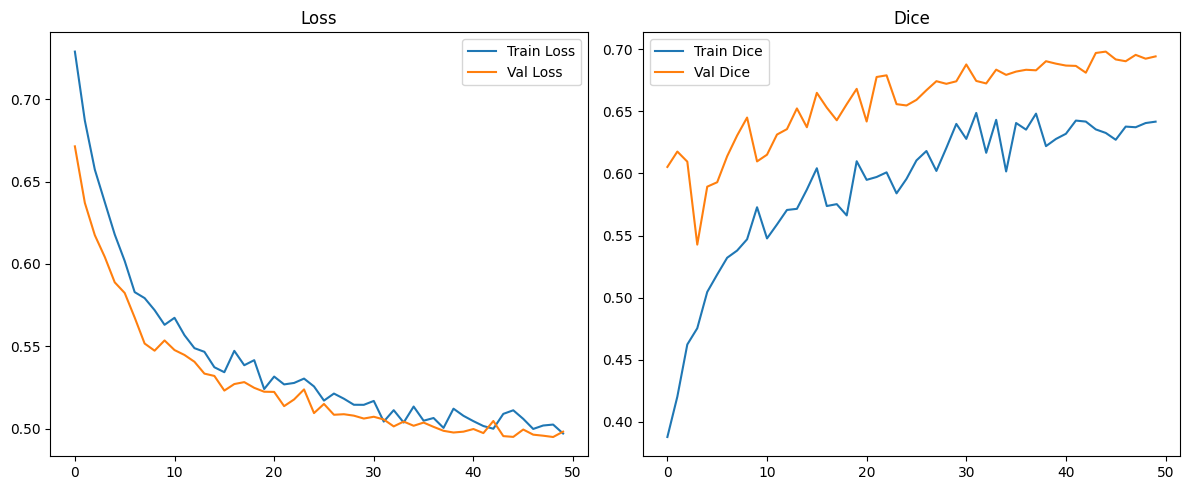

NameError: name 'gc' is not defined

In [14]:
# ============================================================
# Cell 10 — Swin Optimizer + Training Loop
# ============================================================
from tqdm import tqdm
import numpy as np
import torch
import time
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_auc_score

s1_optimizer = torch.optim.AdamW(swin_model.parameters(), lr=8e-5, weight_decay=1e-5)
s1_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    s1_optimizer, mode='max', patience=3, factor=0.5
)
# FIX: torch.cuda.amp.GradScaler() is deprecated in PyTorch 2.x.
# Use torch.amp.GradScaler("cuda") instead.
s1_scaler = torch.amp.GradScaler("cuda")

_swin_loss = BCEDiceLoss(bce_weight=0.4, dice_weight=0.6)

EARLY_STOPPING = 15
NUM_EPOCHS     = 50
swin_ckpt      = "swin_model_best.pth"
start_epoch    = 1
best_swin      = 0.0

if os.path.exists(swin_ckpt):
    print("🔁 Resuming from checkpoint...")
    ckpt = torch.load(swin_ckpt, map_location=device)
    swin_model.load_state_dict(ckpt["model_state"], strict=False)
    s1_optimizer.load_state_dict(ckpt["optimizer_state"])
    s1_scheduler.load_state_dict(ckpt["scheduler_state"])
    best_swin   = ckpt.get("best_score", 0.0)
    start_epoch = ckpt.get("epoch", 0) + 1
    print(f"✅ Resumed from Epoch {start_epoch - 1} | Best Dice = {best_swin:.4f}")
else:
    print("🚀 Starting fresh training.")

swin_hist = {k: [] for k in [
    "train_loss", "val_loss",
    "train_dice", "val_dice",
    "train_iou", "val_iou",
    "train_accuracy", "val_accuracy",
    "train_precision", "val_precision",
    "train_recall", "val_recall",
    "train_f1", "val_f1",
    "train_auc", "val_auc",
    "train_specificity", "val_specificity",
]}

swin_pat = 0
print("=== 🌀 Training: Swin Transformer UNet ===")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    t0 = time.time()
    swin_model.train()
    train_loss, batch_metrics = 0.0, []

    progress = tqdm(train_loader_shared, desc=f"[Train E{epoch:02d}]", leave=False)
    for imgs, masks in progress:
        imgs, masks = imgs.to(device), masks.to(device)
        s1_optimizer.zero_grad()
        # FIX: torch.amp.autocast("cuda") replaces deprecated torch.cuda.amp.autocast()
        with torch.amp.autocast("cuda"):
            logits = swin_model(imgs)
            loss   = _swin_loss(logits, masks)
        s1_scaler.scale(loss).backward()
        s1_scaler.step(s1_optimizer)
        s1_scaler.update()
        train_loss += loss.item() * imgs.size(0)
        batch_metrics.append(compute_metrics_batch_logits(logits.detach(), masks.detach()))
        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{safe_mean([m['dice'] for m in batch_metrics]):.4f}"
        )

    tr_loss = train_loss / len(train_loader_shared.dataset)
    # FIX: use safe_mean so NaN AUC values on all-zero masks don't corrupt the average
    tr_m    = {k: safe_mean([m[k] for m in batch_metrics]) for k in batch_metrics[0]}

    swin_model.eval()
    val_loss, val_metrics = 0.0, []
    with torch.no_grad():
        for imgs, masks in val_loader_shared:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = swin_model(imgs)
            loss   = _swin_loss(logits, masks)
            val_loss += loss.item() * imgs.size(0)
            val_metrics.append(compute_metrics_batch_logits(logits, masks))

    val_loss /= len(val_loader_shared.dataset)
    val_m     = {k: safe_mean([m[k] for m in val_metrics]) for k in val_metrics[0]}

    s1_scheduler.step(val_m["dice"])

    print(
        f"[E{epoch:02d}] TL={tr_loss:.4f} | VL={val_loss:.4f} | "
        f"TD={tr_m['dice']:.4f} | VD={val_m['dice']:.4f} | "
        f"IoU={val_m['iou']:.4f} | Acc={val_m['accuracy']:.4f} | "
        f"Prec={val_m['precision']:.4f} | Rec={val_m['recall']:.4f} | "
        f"F1={val_m['f1']:.4f} | AUC={val_m['auc']:.4f} | "
        f"Spec={val_m['specificity']:.4f}"
    )

    for k in tr_m:
        swin_hist[f"train_{k}"].append(tr_m[k])
        swin_hist[f"val_{k}"].append(val_m[k])
    swin_hist["train_loss"].append(tr_loss)
    swin_hist["val_loss"].append(val_loss)

    if val_m["dice"] > best_swin + 1e-4:
        best_swin = val_m["dice"]
        swin_pat  = 0
        torch.save({
            "epoch": epoch,
            "model_state": swin_model.state_dict(),
            "optimizer_state": s1_optimizer.state_dict(),
            "scheduler_state": s1_scheduler.state_dict(),
            "best_score": best_swin,
        }, swin_ckpt)
        print(f"💾 Saved best checkpoint (Dice={best_swin:.4f})")
    else:
        swin_pat += 1
        if swin_pat >= EARLY_STOPPING:
            print("🛑 Early stopping triggered.")
            break

    print(f"⏱ Epoch time: {time.time() - t0:.1f}s")

print(f"\n🏁 Training complete. Best Val Dice = {best_swin:.4f}")
torch.save(swin_hist, "swin_history.pt")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(swin_hist["train_loss"], label="Train Loss")
axes[0].plot(swin_hist["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(swin_hist["train_dice"], label="Train Dice")
axes[1].plot(swin_hist["val_dice"],   label="Val Dice")
axes[1].set_title("Dice"); axes[1].legend()
plt.tight_layout(); plt.show()

gc.collect(); torch.cuda.empty_cache()



In [15]:
# ============================================================
# Cell 11 — Save Artifacts
# ============================================================
from datetime import datetime

SAVE_DIR  = "swin_training_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

final_ckpt_path = os.path.join(SAVE_DIR, f"swin_model_final_{timestamp}.pth")
torch.save({
    "model_state":      swin_model.state_dict(),
    "optimizer_state":  s1_optimizer.state_dict(),
    "scheduler_state":  s1_scheduler.state_dict(),
    "epoch_trained":    len(swin_hist["train_loss"]),
    "best_dice":        best_swin,
}, final_ckpt_path)
print(f"💾 Final checkpoint → {final_ckpt_path}")

history_path = os.path.join(SAVE_DIR, f"swin_history_{timestamp}.pt")
torch.save(swin_hist, history_path)

json_hist_path = os.path.join(SAVE_DIR, f"swin_history_{timestamp}.json")
with open(json_hist_path, "w") as f:
    json.dump(swin_hist, f, indent=4)
print(f"📊 History saved → {history_path}")

config = {
    "timestamp":      datetime.now().isoformat(),
    "device":         str(device),
    "image_size":     IMG_SIZE,
    "batch_size":     BATCH_SIZE,
    "epochs_trained": len(swin_hist["train_loss"]),
    "best_val_dice":  round(best_swin, 5),
    "optimizer":      "AdamW",
    "lr":             s1_optimizer.param_groups[0]["lr"],
    "scheduler":      "ReduceLROnPlateau",
    "early_stopping": EARLY_STOPPING,
    "encoder":        ENCODER_NAME,
    "losses":         ["BCEWithLogitsLoss", "SoftDiceLoss"],
    "checkpoint_best":  swin_ckpt,
    "checkpoint_final": final_ckpt_path,
}
config_path = os.path.join(SAVE_DIR, f"swin_config_{timestamp}.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)
print(f"🧩 Config saved → {config_path}")

weights_path = os.path.join(SAVE_DIR, f"swin_weights_only_{timestamp}.pth")
torch.save(swin_model.state_dict(), weights_path)
print(f"🧠 Weights only → {weights_path}")

print(f"\n🏁 Best Val Dice: {best_swin:.4f} | Epochs: {len(swin_hist['train_loss'])}")
torch.cuda.empty_cache()


💾 Final checkpoint → swin_training_artifacts/swin_model_final_20260423_175445.pth
📊 History saved → swin_training_artifacts/swin_history_20260423_175445.pt
🧩 Config saved → swin_training_artifacts/swin_config_20260423_175445.json
🧠 Weights only → swin_training_artifacts/swin_weights_only_20260423_175445.pth

🏁 Best Val Dice: 0.6980 | Epochs: 50


✅ Loaded best model | Dice=0.6980


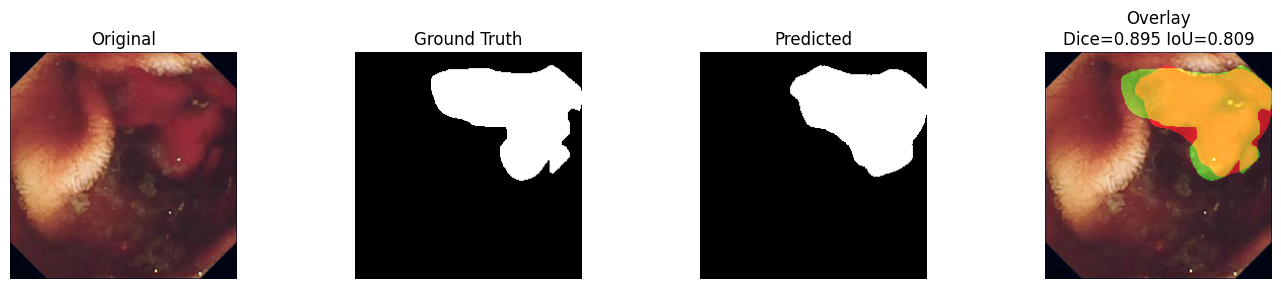

  Dice=0.895 | IoU=0.809 | Prec=0.921 | Rec=0.870 | F1=0.895 | Acc=0.958


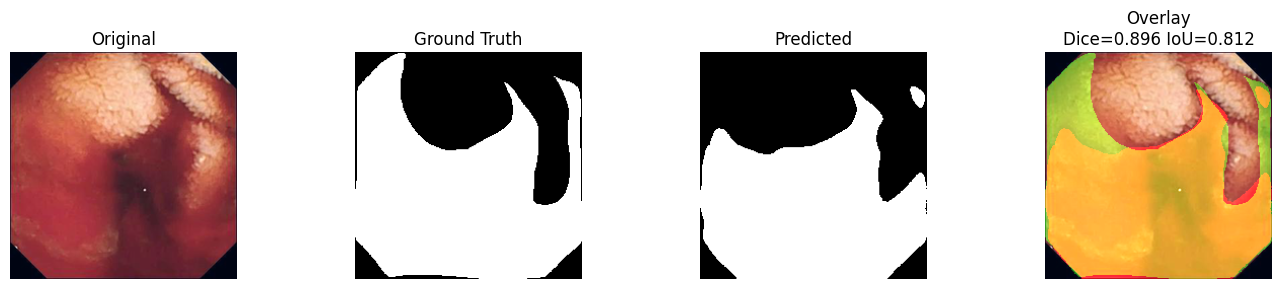

  Dice=0.896 | IoU=0.812 | Prec=0.969 | Rec=0.834 | F1=0.896 | Acc=0.877


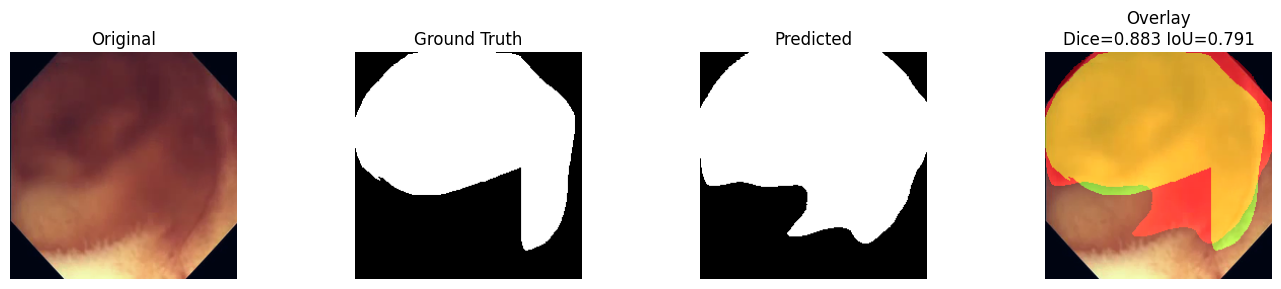

  Dice=0.883 | IoU=0.791 | Prec=0.820 | Rec=0.957 | F1=0.883 | Acc=0.863


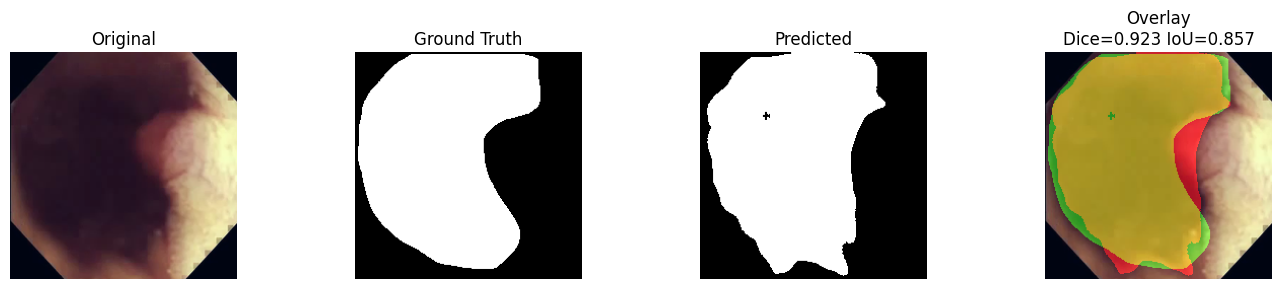

  Dice=0.923 | IoU=0.857 | Prec=0.922 | Rec=0.924 | F1=0.923 | Acc=0.915


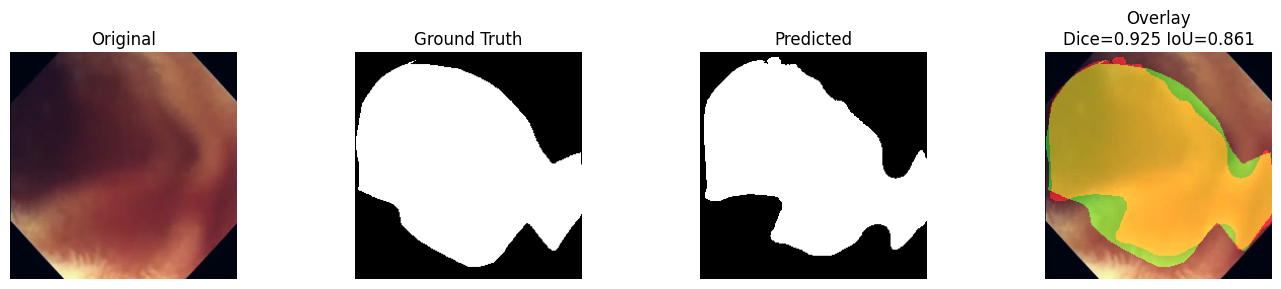

  Dice=0.925 | IoU=0.861 | Prec=0.983 | Rec=0.874 | F1=0.925 | Acc=0.914

🏁 Overall (50 samples, 5 displayed):
  Dice        : 0.5755
  Iou         : 0.5201
  Precision   : 0.2599
  Recall      : 0.2914
  F1          : 0.2555
  Accuracy    : 0.9304


In [17]:
# ============================================================
# Cell 12 — Evaluation & Visualization
# ============================================================
ckpt = torch.load(swin_ckpt, map_location=device)
swin_model.load_state_dict(ckpt["model_state"], strict=False)
print(f"✅ Loaded best model | Dice={ckpt.get('best_score', 0):.4f}")


def compute_metrics_single(pred_np, gt_np, eps=1e-6):
    pred = pred_np > 0.5
    gt   = gt_np   > 0.5
    TP   = int((pred & gt).sum())
    FP   = int((pred & ~gt).sum())
    FN   = int((~pred & gt).sum())
    TN   = int((~pred & ~gt).sum())
    dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    iou  = (TP + eps)     / (TP + FP + FN + eps)
    prec = TP / (TP + FP + eps)
    rec  = TP / (TP + FN + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    acc  = (TP + TN) / (TP + TN + FP + FN + eps)
    return {"dice": dice, "iou": iou, "precision": prec,
            "recall": rec, "f1": f1, "accuracy": acc}


def show_filtered_predictions(model, loader, min_dice=0.8, max_dice=0.95, num_samples=50):
    model.eval()
    all_metrics, displayed, qualified = [], 0, 0

    with torch.no_grad():
        for imgs, masks in loader:
            if displayed >= num_samples:
                break
            imgs, masks = imgs.to(device), masks.to(device)
            preds_bin   = (torch.sigmoid(model(imgs)) > 0.5).float()

            for i in range(imgs.size(0)):
                if displayed >= num_samples:
                    break

                img_np  = imgs[i].permute(1, 2, 0).cpu().numpy()
                img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
                mask_np = masks[i].squeeze().cpu().numpy()
                pred_np = preds_bin[i].squeeze().cpu().numpy()

                m = compute_metrics_single(pred_np, mask_np)
                all_metrics.append(m)
                displayed += 1

                if min_dice <= m["dice"] <= max_dice:
                    qualified += 1
                    overlay = img_np.copy()
                    overlay[..., 0] = np.clip(overlay[..., 0] + pred_np * 0.5, 0, 1)
                    overlay[..., 1] = np.clip(overlay[..., 1] + mask_np * 0.5, 0, 1)

                    fig, axs = plt.subplots(1, 4, figsize=(14, 3))
                    axs[0].imshow(img_np);              axs[0].set_title("Original")
                    axs[1].imshow(mask_np, cmap="gray"); axs[1].set_title("Ground Truth")
                    axs[2].imshow(pred_np, cmap="gray"); axs[2].set_title("Predicted")
                    axs[3].imshow(overlay)
                    axs[3].set_title(f"Overlay\nDice={m['dice']:.3f} IoU={m['iou']:.3f}")
                    for ax in axs:
                        ax.axis("off")
                    plt.tight_layout(); plt.show()

                    print(f"  Dice={m['dice']:.3f} | IoU={m['iou']:.3f} | "
                          f"Prec={m['precision']:.3f} | Rec={m['recall']:.3f} | "
                          f"F1={m['f1']:.3f} | Acc={m['accuracy']:.3f}")

    avg = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}
    print(f"\n🏁 Overall ({displayed} samples, {qualified} displayed):")
    for k, v in avg.items():
        print(f"  {k.capitalize():<12}: {v:.4f}")
    torch.save(avg, "swin_val_metrics.pt")
    return avg


avg_metrics = show_filtered_predictions(swin_model, val_loader_shared)



In [18]:
# ============================================================
# Cell 13 — Full Dataset Evaluation
# ============================================================

def compute_metrics_full_dataset(model, loader, threshold=0.5, eps=1e-6):
    model.eval()
    all_metrics = []

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating"):
            imgs, masks = imgs.to(device), masks.to(device)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > threshold).float()

            for i in range(imgs.size(0)):
                pred_i = preds[i].squeeze().cpu().numpy().astype(bool)
                gt_i   = masks[i].squeeze().cpu().numpy().astype(bool)

                TP = int(np.logical_and(pred_i,  gt_i).sum())
                FP = int(np.logical_and(pred_i,  ~gt_i).sum())
                FN = int(np.logical_and(~pred_i, gt_i).sum())
                TN = int(np.logical_and(~pred_i, ~gt_i).sum())

                dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
                iou  = (TP + eps)     / (TP + FP + FN + eps)
                prec = TP / (TP + FP + eps)
                rec  = TP / (TP + FN + eps)
                f1   = 2 * prec * rec / (prec + rec + eps)
                acc  = (TP + TN) / (TP + TN + FP + FN + eps)
                spec = TN / (TN + FP + eps)

                # FIX: Skip AUC for all-zero / all-one masks (non-bleeding images)
                # instead of catching ValueError and returning 0.0, which dragged
                # mean AUC below 0.5 (worse than random). Use NaN + safe_mean.
                gt_flat   = gt_i.ravel().astype(int)
                prob_flat = probs[i].squeeze().cpu().numpy().ravel()
                try:
                    if gt_flat.sum() > 0 and (1 - gt_flat).sum() > 0:
                        auc = float(roc_auc_score(gt_flat, prob_flat))
                    else:
                        auc = float('nan')
                except Exception:
                    auc = float('nan')

                all_metrics.append({
                    "dice": dice, "iou": iou,
                    "precision": prec, "recall": rec,
                    "f1": f1, "accuracy": acc,
                    "specificity": spec, "auc": auc
                })

    avg = {k: safe_mean([m[k] for m in all_metrics]) for k in all_metrics[0]}

    print("\n🏁 Full Validation Metrics:")
    print("─" * 44)
    for k, v in avg.items():
        print(f"  {k.capitalize():<14}: {v:.4f}")
    print("─" * 44)

    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = f"swin_val_metrics_full_{ts}.pt"
    torch.save(avg, path)
    print(f"💾 Saved → {path}")
    return avg


val_metrics = compute_metrics_full_dataset(swin_model, val_loader_shared)



Evaluating: 100%|██████████| 33/33 [00:04<00:00,  7.11it/s]


🏁 Full Validation Metrics:
────────────────────────────────────────────
  Dice          : 0.6268
  Iou           : 0.5695
  Precision     : 0.3146
  Recall        : 0.3092
  F1            : 0.2910
  Accuracy      : 0.9469
  Specificity   : 0.9578
  Auc           : 0.9395
────────────────────────────────────────────
💾 Saved → swin_val_metrics_full_20260423_175527.pt


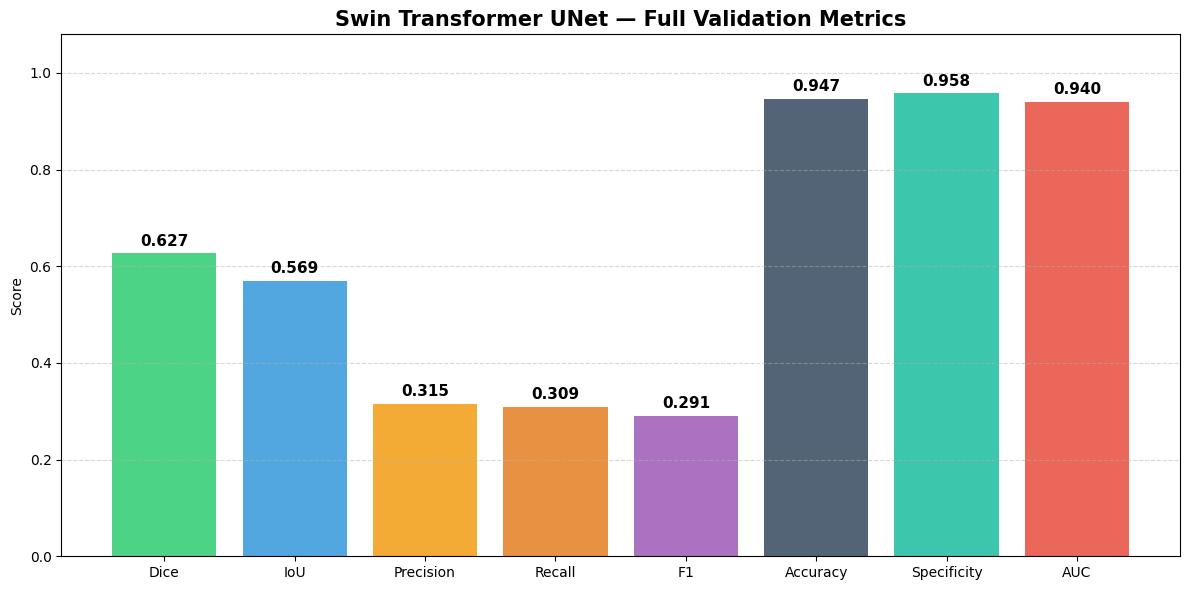

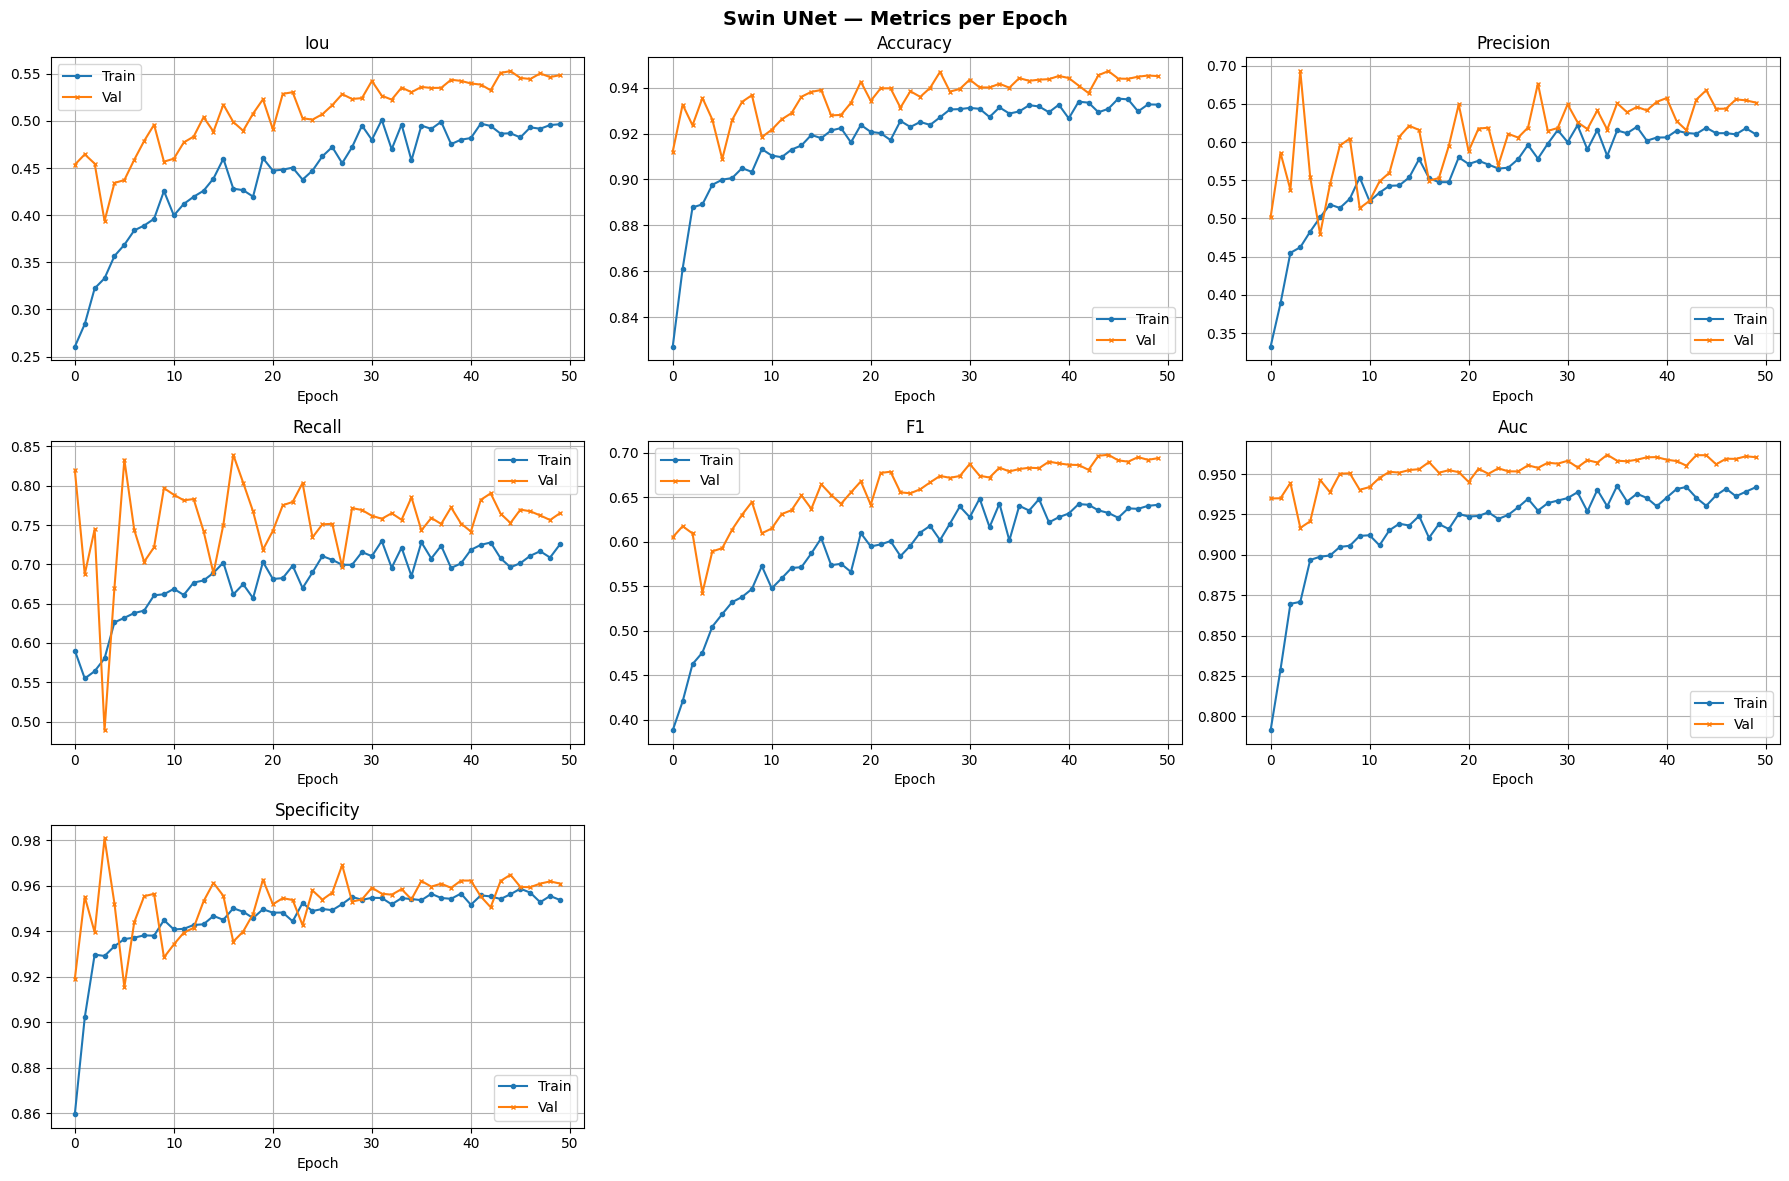

In [19]:
# ============================================================
# Cell 14 — Metrics Bar Chart + Epoch Plots
# ============================================================

# Bar chart of final validation metrics
metric_names  = ["Dice", "IoU", "Precision", "Recall", "F1", "Accuracy", "Specificity", "AUC"]
metric_values = [val_metrics.get(m.lower(), 0.0) for m in metric_names]
colors        = ["#2ecc71","#3498db","#f39c12","#e67e22","#9b59b6","#34495e","#1abc9c","#e74c3c"]

plt.figure(figsize=(12, 6))
bars = plt.bar(metric_names, metric_values, color=colors, alpha=0.85)
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title("Swin Transformer UNet — Full Validation Metrics", fontsize=15, fontweight='bold')
plt.ylabel("Score"); plt.ylim(0, 1.08)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# Epoch-by-epoch plots for all tracked metrics
metrics_to_plot = ["iou", "accuracy", "precision", "recall", "f1", "auc", "specificity"]
plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(3, 3, i)
    plt.plot(swin_hist[f"train_{metric}"], label="Train", marker='o', markersize=3)
    plt.plot(swin_hist[f"val_{metric}"],   label="Val",   marker='x', markersize=3)
    plt.title(metric.capitalize()); plt.xlabel("Epoch")
    plt.grid(True); plt.legend()
plt.suptitle("Swin UNet — Metrics per Epoch", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()